In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

path_results = Path("../results")

to_compare = [
    [
        "aug_cnnfa_4l_short_input_edt_fp_strict_fix",
        "aug_cnnfa_4l_short_input_edt_fp_strict_fix9",
    ],
    [
        "paug_cnn_4l_short_input_edt_fp_aneu_fix",
        "paug_cnn_4l_short_input_edt_fp_aneu_fix9",
    ],
    [
        "paug_cnn_4l_short_input_edt_fp_strict_aneu_fix",
        "paug_cnn_4l_short_input_edt_fp_strict_aneu_fix9",
    ],
    [
        "paug_cnn_4l_short_input_edt_fp_strict_fix",
        "paug_cnn_4l_short_input_edt_fp_strict_fix9",
    ],
    [
        "opaug_cnn_4l_short_input_edt_fp_strict_fix",
        "opaug_cnn_4l_short_input_edt_fp_strict_fix_august",
    ],
    ["decoder_only_no_rec_input_edt", "decoder_only_no_rec_input_edt_august"],
    ["decoder_only_no_rec_input_edt", "decoder_only_no_rec_input_edt2"],
    ["decoder_only_no_rec_input_edt2", "decoder_only_no_rec_input_edt_august"],
    [
        "aug_cnn_4l_short_input_edt_fp_strict_fix",
        "aug_cnn_4l_short_input_edt_fp_strict_fix2",
    ],
]

datasets = ["hospital140", "cmha", "internal_test", "external"]


ious = [0.1, 0.2, 0.3]

modes = ["mode_base", "mode_1", "mode_3", "mode_5"]

comp = -1


stats = []
pair = to_compare[comp]

columns = [
    "dataset",
    "model",
    "chkpt",
    "iou",
    "mode",
    "se_0.1",
    "se_0.2",
    "se_0.5",
    "se_1.0",
    "se_2.0",
    "se_4.0",
    "se_8.0",
]

for dataset in datasets:
    for model in pair:
        file_chkpts = path_results / dataset / model
        # get all subfolders with the word "inf"
        subfolders = [
            str(file.name)
            for file in file_chkpts.iterdir()
            if file.is_dir() and "inf" in file.name
        ]
        for inf in subfolders:
            inf_append = inf.replace("inference_", "")
            for iou in ious:
                for mode in modes:
                    path_csv_file = (
                        file_chkpts / f"{mode}/iou{iou}_froc_{inf_append}/froc.csv"
                    )
                    try:
                        df_froc = pd.read_csv(path_csv_file)
                    except:
                        print(f"File not found: {path_csv_file}")
                        continue
                    # print(path_csv_file)
                    sensitivities = df_froc.iloc[0, 1:].values.tolist()
                    stats.append(
                        [
                            dataset,
                            model,
                            inf_append,
                            iou,
                            mode,
                            *sensitivities,
                        ]
                    )

In [38]:
df_results = pd.DataFrame(stats, columns=columns)

In [39]:
df_results

,dataset,model,chkpt,iou,mode,se_0.1,se_0.2,se_0.5,se_1.0,se_2.0,se_4.0,se_8.0
0,hospital140,aug_cnn_4l_short_input_edt_fp_strict_fix,10k,0.1,mode_base,0.557,0.637,0.708,0.750,0.816,0.849,0.882
1,hospital140,aug_cnn_4l_short_input_edt_fp_strict_fix,10k,0.1,mode_1,0.575,0.656,0.722,0.792,0.830,0.863,0.901
2,hospital140,aug_cnn_4l_short_input_edt_fp_strict_fix,10k,0.1,mode_3,0.557,0.642,0.712,0.769,0.825,0.858,0.896
3,hospital140,aug_cnn_4l_short_input_edt_fp_strict_fix,10k,0.1,mode_5,0.575,0.656,0.722,0.792,0.830,0.873,0.910
4,hospital140,aug_cnn_4l_short_input_edt_fp_strict_fix,10k,0.2,mode_base,0.557,0.637,0.708,0.750,0.816,0.849,0.882
...,...,...,...,...,...,...,...,...,...,...,...,...
619,external,aug_cnn_4l_short_input_edt_fp_strict_fix2,final,0.2,mode_5,0.921,0.941,0.941,0.950,0.960,0.960,0.960
620,external,aug_cnn_4l_short_input_edt_fp_strict_fix2,final,0.3,mode_base,0.881,0.921,0.931,0.931,0.941,0.950,0.950
621,external,aug_cnn_4l_short_input_edt_fp_strict_fix2,final,0.3,mode_1,0.911,0.921,0.931,0.941,0.950,0.950,0.950
622,external,aug_cnn_4l_short_input_edt_fp_strict_fix2,final,0.3,mode_3,0.861,0.901,0.911,0.911,0.921,0.931,0.931


In [40]:
df_results["chkpt"].unique()

array(['10k', '12k', '14k', '16k', '4k', '8k', 'final', '13k'],
      dtype=object)

aug_cnn_4l_short_input_edt_fp_strict_fix hospital140 mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix2 hospital140 mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix cmha mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix2 cmha mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix internal_test mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix2 internal_test mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix external mode_1 0.2 16k
aug_cnn_4l_short_input_edt_fp_strict_fix2 external mode_1 0.2 16k


Text(0.5, 0.98, 'FROC Curves Comparison, IoU 0.2, Checkpoint: 16k, Mode: mode_1')

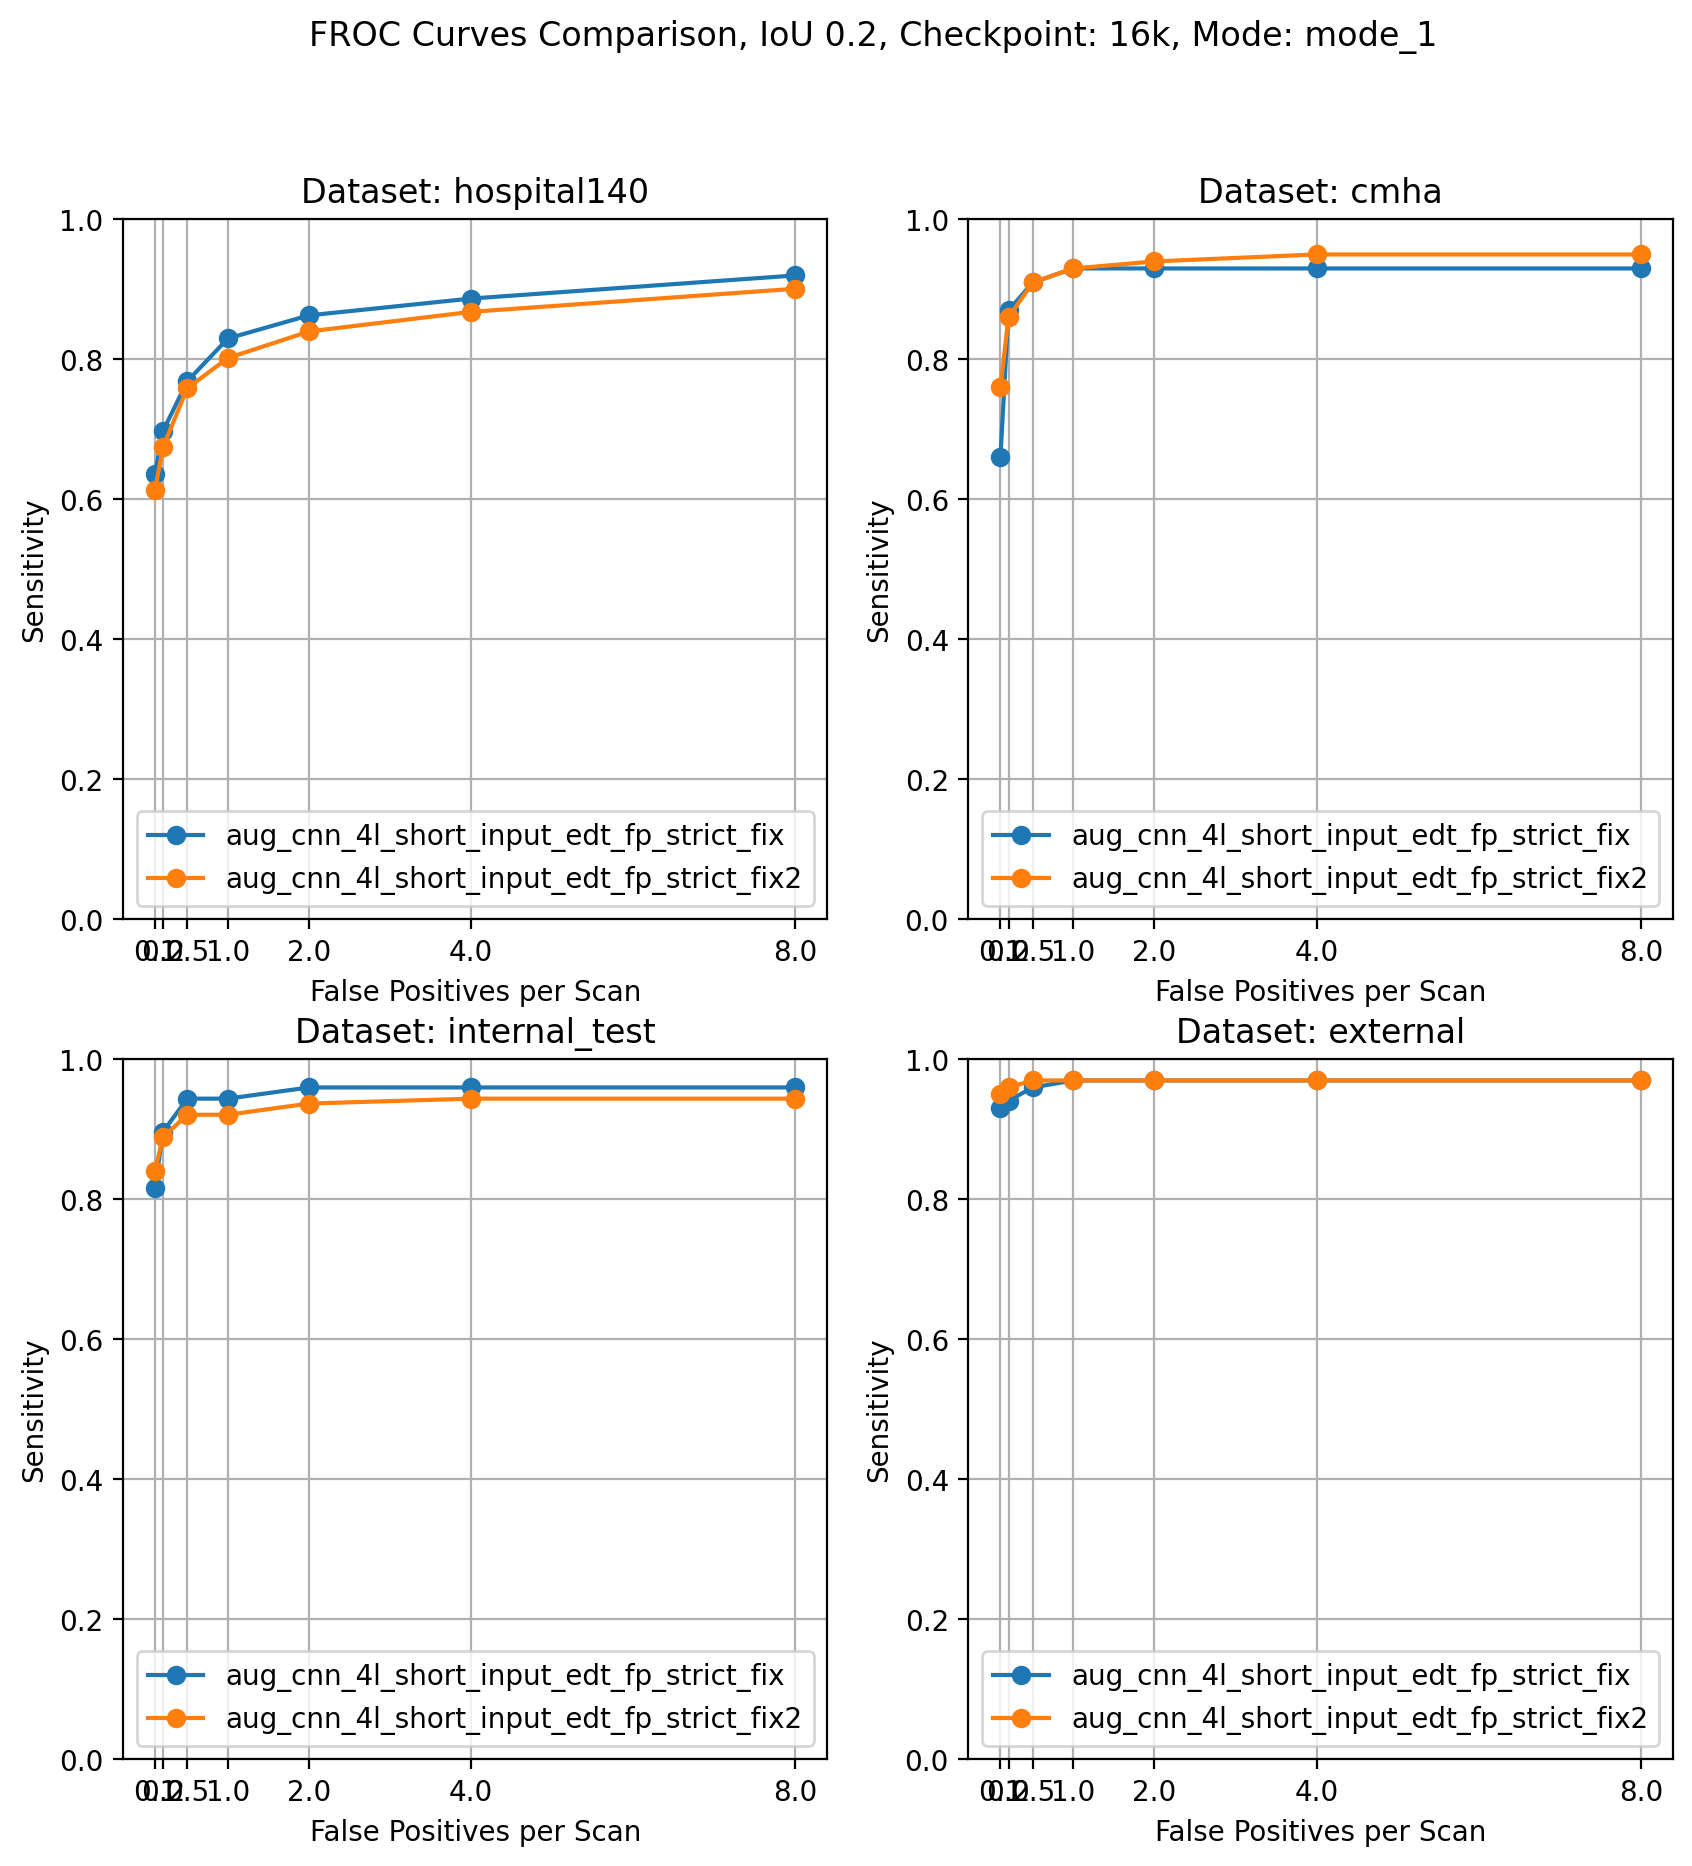

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), dpi=200)

datasets = ["hospital140", "cmha", "internal_test", "external"]
mode = "mode_1"
iou = 0.2
chkpt = "16k"

for i, dataset in enumerate(datasets):
    ax_i = ax[i // 2, i % 2]
    for model in pair:
        print(model, dataset, mode, iou, chkpt)
        df_plot = df_results[
            (df_results["dataset"] == dataset)
            & (df_results["mode"] == mode)
            & (df_results["iou"] == iou)
            & (df_results["chkpt"] == chkpt)
            & (df_results["model"] == model)
        ]
        fp_per_scan = [0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0]

        sensitivities = df_plot.iloc[0, 5:].values.tolist()
        ax_i.plot(
            fp_per_scan,
            sensitivities,
            marker="o",
            label=model,
        )
    ax_i.set_title(f"Dataset: {dataset}")
    ax_i.set_xlabel("False Positives per Scan")
    ax_i.set_ylabel("Sensitivity")
    ax_i.set_xticks(fp_per_scan)
    ax_i.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_i.set_ylim(0, 1)
    ax_i.grid(True)
    ax_i.legend()
fig.suptitle(f"FROC Curves Comparison, IoU {iou}, Checkpoint: {chkpt}, Mode: {mode}")